# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

from VirtualSAS_theory import VirtualSAS_theory

from AFL.double_agent import *
from AFL.double_agent.PyTorchExtrapolator import DirichletGPExtrapolator 

from tqdm.auto import tqdm 
from typing import Optional, Union, List, Tuple, Dict, Any
import textwrap

### Create Virtual Instrument

In [3]:
from AFL.automation.APIServer.data.DataTrashcan import DataTrashcan

boundary_dataset = xr.load_dataset('250610-extrap_expand_dataset.nc')
boundary_dataset.close()

reference_data_path = './SANS/'
inst_client = VirtualSAS_theory()
inst_client.data = DataTrashcan()
boundary_dataset['labels'] = boundary_dataset.labels.astype(str)
inst_client.boundary_dataset = boundary_dataset
inst_client.trace_boundaries(hull_tracing_ratio=0.25)

# specify reference data
for fname in ['low_q.ABS', 'med_q.ABS', 'high_q.ABS']:
    data = pd.read_csv(str(pathlib.Path(reference_data_path) / fname),sep=r'\s+')#, delim_whitespace=True)
    inst_client.add_configuration(
        q=list(data.q),
        I=list(data.I),
        dI=list(data.dI),
        dq=list(data.dq),
        reset=False
    )

inst_client.add_sasview_model(
    label='2',
    model_name='polymer_excl_volume',
    model_kw={
        'scale': 1.0,
        'background': 1.0,
        'rg': 100.0,
    }
)

inst_client.add_sasview_model(
    label='1',
    model_name='sphere',
    model_kw={
        'scale': 0.5,
        'background': 1.0,
        'sld': 1.0,
        'sld_solvent': 6.0,
        'radius': 10,
    }
)

inst_client.add_sasview_model(
    label='0',
    model_name='power_law',
    model_kw={
        'scale': 1e-7,
        'background': 1.0,
        'power': 4.0,
    }
)
inst_client

## Initial Dataset

In [4]:
ds_list = []
for temp in [0,10,20,30,40,50]:
    ds = inst_client.simple_expose({'protein':40,'temperature':temp,'glycerol':5})
    ds = ds.rename({'composition': 'design_space', 'component':'ds_dim'})
    ds['phases'] = int(ds.attrs['labels'])
    ds_list.append(ds)

ds_init = xr.concat(ds_list, dim='sample')
ds_init

<xarray.Dataset> Size: 43kB
Dimensions:       (sample: 6, q: 281, ds_dim: 3)
Coordinates:
  * q             (q) float64 2kB 0.003836 0.004348 0.004859 ... 0.6293 0.6334
  * ds_dim        (ds_dim) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    I             (sample, q) float64 13kB 1.95 1.937 1.923 ... 1.0 1.0 1.0
    I_noiseless   (sample, q) float64 13kB 1.95 1.937 1.923 ... 1.0 1.0 1.0
    dI            (sample, q) float64 13kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    design_space  (sample, ds_dim) int64 144B 40 0 5 40 10 5 ... 40 40 5 40 50 5
    phases        (sample) int64 48B 2 1 1 1 0 0
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

In [5]:
def minmax_normalize(arr: np.ndarray,
                    axis: Optional[Union[int, Tuple[int, ...]]] = None,
                    eps: float = 1e-8
                ) -> np.ndarray:
    """
    Min-max normalize a NumPy array along a given axis or globally.

    Parameters:
    -----------
    arr : np.ndarray
        Input array (1D or multi-dimensional).
    axis : Optional[int or Tuple[int, ...]]
        Axis or axes along which to normalize. If None, normalize globally.
    eps : float
        Small epsilon to avoid division by zero.

    Returns:
    --------
    normalized : np.ndarray
        Normalized array with same shape as input, scaled to [0, 1].
    """
    arr = np.asarray(arr)
    min_val = np.min(arr, axis=axis, keepdims=True)
    max_val = np.max(arr, axis=axis, keepdims=True)
    normalized = (arr - min_val) / (max_val - min_val + eps)
    return normalized

### Modeling hierarchical costs in different design variables

In [6]:
class DesignSpaceHierarchyCost(PipelineOp):
    def __init__(
        self,
        grid_variable: str = None,
        grid_dim:str =None,
        component_dim:str=None,
        variables_order : List[str] = None,
        variables_offsets : List[float] = None,
        output_variable: str = None,
        name: str = "DesignSpaceHierarchyCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=[grid_variable], output_variable=output_variable
        )
        self.variables_order = variables_order
        self.variables_offsets = variables_offsets
        self.grid_variable = grid_variable
        self.grid_dim = grid_dim
        self.component_dim = component_dim
        self.iteration = 1

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Compute and store normalized cost over the full grid."""
        grid = dataset[self.grid_variable]

        cost_grid = self.evaluate_cost(query=grid)

        self.output[self.output_variable] = xr.DataArray(cost_grid, dims=self.grid_dim)
        self.output[self.output_variable].attrs[
            "description"
        ] = f"Cost per sample evaluated on {self.input_variable}"

        return self
    
    def evaluate_cost(self,
                      query: xr.DataArray,
                    ) -> np.ndarray:
        """Compute cost for each query point using previously sampled data."""
        num_queries = query.shape[0]
        k = query.shape[1]
        output = np.zeros(num_queries)
        for i in range(num_queries):
            w = np.sort(np.random.dirichlet(np.ones(k),size=1))[0]
            dim_cost = []
            for j in range(k):
                ell = 1/((w[j]*self.iteration)+1)
                x = query.sel({self.component_dim: self.variables_order[j]}).values[i]
                f_x_t = ell*np.exp(-(np.abs(x-self.variables_offsets[j])*ell))
                dim_cost.append(1-f_x_t)
            output[i] = np.prod(np.array(dim_cost))

        self.iteration += 1
        return output

### Modeling unknown feasibility constraints

In [7]:
class FeasibilityLabeler(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        output_variable: str = None,
        dim: str = "sample",
        name: str = "FeasibilityLabeler",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=input_variable, 
            output_variable=output_variable,
        )
        self.dim = dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Label samples as feasible or infeasible based on cost."""
        labels = dataset[self.input_variable].values
        is_feasible = np.where(labels == 0, 0, 1)  # 1 for feasible, 0 for infeasible
        self.output[self.output_variable] = xr.DataArray(is_feasible, dims=[self.dim])
        self.output[self.output_variable].attrs[
            "description"
        ] = f"Feasibility labels based on {self.input_variable}"

        return self

### Line sample temperature

In [8]:
class TemperatureLineSampler(PipelineOp):
    def __init__(
        self,
        input_variable:str = "next_sample",
        input_dim:str = "ds_dim",
        composition_dims :  List[str] = None,
        temperature_dim:str = "temperature",
        grid_variable:str = "design_space_grid",
        grid_dim:str = "ds_grid",
        probability_variable: str = "feasibility_y_prob",
        min_probability: float = 0.1,
        max_probability: float = 0.9,
        n_temp_points: int = 10,
        output_variable: str = "temperature_line_samples",
        name: str = "TemperatureLineSampler",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=[input_variable, probability_variable], 
            output_variable=output_variable
        )
        self.input_variable = input_variable
        self.input_dim = input_dim
        self.composition_dims = composition_dims
        self.temperature_dim = temperature_dim
        self.grid_variable = grid_variable 
        self.grid_dim = grid_dim
        self.probability_variable = probability_variable
        self.min_probability = min_probability
        self.max_probability = max_probability
        self.n_temp_points = n_temp_points

    def calculate(self, dataset: xr.Dataset) -> Self:
        next_sample = dataset[self.input_variable]
        target_composition = next_sample.sel({self.input_dim:self.composition_dims}).values
        t_min = next_sample.sel({"ds_dim":self.temperature_dim}).values

        grid = dataset[self.grid_variable]
        grid_composition = grid.sel({self.input_dim:self.composition_dims}).values

        squared_distances = np.sum((target_composition - grid_composition) ** 2, axis=1)
        all_temp_idx = np.argwhere(squared_distances<1e-5)

        probabilities = dataset.feasibility_y_prob
        squared_distances = np.sum((next_sample.values - grid.values) ** 2, axis=1)
        next_sample_idx = np.argwhere(squared_distances<1e-5)

        all_temp_probs = probabilities.values[all_temp_idx]
        next_sample_probs = probabilities.values[next_sample_idx].item()

        idx_higher_than_next_sample = all_temp_idx[all_temp_probs>=next_sample_probs]
        idx_lower_than_max_prob = all_temp_idx[all_temp_probs<=self.max_probability]
        line_samples_idx = np.intersect1d(idx_higher_than_next_sample, idx_lower_than_max_prob)
        line_samples = grid.values[line_samples_idx]

        output = xr.DataArray(line_samples, 
                            dims=["line_samples", self.input_dim],
                            coords={"ds_dim": grid.coords["ds_dim"]}
                        )
        self.output[self.output_variable] = output
        self.output[self.output_variable].attrs["description"] = textwrap.dedent("""
        Samples along the temperature axis that have higher probability of being feasible
        with minimum specified by the point that maximizes the acquisition
        function for determining phase boundaries (along with any associated costs)
        """).strip()

        return self   


### Create cost-aware acquisition function

In [9]:
class AcquisitionWithCost(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        cost_variables: List[str] = None,
        grid_dim: str = "grid",
        output_variable: str = None,
        name: str = "AcquisitonPerUnitCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=[input_variable] + cost_variables, output_variable=output_variable
        )
        self.cost_variable = cost_variables
        self.grid_dim = grid_dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Apply this `PipelineOp` to the supplied `xarray.Dataset` using xarray operations only."""

        acqv = dataset[self.input_variable]
        cost = dataset[self.cost_variable]

        # Compute acquisition per unit cost
        # Q(x,t)/C(x,t)

        # acqv_cost = acqv / (cost + 1e-9)
        # norm_acqv_cost = minmax_normalize(acqv_cost)

        # Add acquisition and acquiring cost Q(x,t) + C(x,t)
        # This reduces the absurd case of sampling existing points that have zero cost
        # this maximizes the acquisition per unit cost
        # we are however assuming that acquisition and cost are measured in the same units.

        # norm_acqv_cost = minmax_normalize(acqv.values) - minmax_normalize(cost.values)

        # Anther option is to Q(x, t)*(1-C(x,t)) following 
        # https://arxiv.org/pdf/1909.03600 Equation 9 
        acqv_cost = acqv.values.copy()
        for var in self.cost_variable:
            cost = dataset[var].values
            acqv_cost *= (1.0-cost)

        # Normalize
        output = xr.DataArray(acqv_cost, dims=self.grid_dim)

        # Store result
        self.output[self.output_variable] = output
        self.output[self.output_variable].attrs["description"] = "Acquisition with Cost (Normalized)"

        return self


### Creatte the pipeline for active learning

In [10]:
with Pipeline(name = "find_boundaries") as p:
    CartesianGrid(
        output_variable="design_space_grid",
        sample_dim="ds_grid",
        component_dim ="ds_dim",
        grid_spec = {'protein':{'min': 0.0, 'max': 80.0, 'steps': 20},
                     'glycerol':{'min': 0.0, 'max': 12.0, 'steps': 20},
                     'temperature':{'min': 0.0, 'max': 50.0, 'steps': 20}}
    )    
    Standardize(
        input_variable="design_space",
        output_variable="normalized_design_space",
        dim="sample",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )
    Standardize(
        input_variable="design_space_grid",
        output_variable="normalized_design_space_grid",
        dim="ds_grid",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )

    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="phases",
        output_prefix="phase",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        params={"learning_rate": 1e-1, "n_iterations": 100, "verbose": False},
        name="DirichletGPExtrapolator-PhaseLabels",
    )

    DesignSpaceHierarchyCost(
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        component_dim="ds_dim",
        variables_order=['temperature', 'protein', 'glycerol'],
        variables_offsets=[0.5, 0.0, 0.0],
        output_variable="hierarchy_cost",
        name="CompositionTemperatureHierarchyCost",
    ) 

    AcquisitionWithCost(
        input_variable="phase_entropy",
        cost_variables=["hierarchy_cost"],
        grid_dim="ds_grid",        
        output_variable="acqv_cost",
        name="AcquisitionWithCost",
    )

    MaxValueAF(
        input_variables=['acqv_cost'],
        grid_variable="design_space_grid",
        grid_dim="ds_grid",
        combine_coeffs=None,
        output_prefix=None,
        output_variable="next_sample",
        decision_rtol=0.05,
        excluded_comps_variables=None,
        excluded_comps_dim=None,
        exclusion_radius=0.001,
        count=1,
        name="MaxValueAF",
    )
    FeasibilityLabeler(
        input_variable="phases",
        output_variable="feasibility_labels",
        dim="sample",
        name="FeasibilityLabeler",
    )
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="feasibility_labels",
        output_prefix="feasibility",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        params={"learning_rate": 1e-1, "n_iterations": 100, "verbose": False},
        name="DirichletGPExtrapolator-FeasibilityLabels",
    )
    TemperatureLineSampler(
        input_variable= "next_sample",
        input_dim = "ds_dim",
        composition_dims = ['protein', 'glycerol'],
        temperature_dim = "temperature",
        grid_variable = "design_space_grid",
        grid_dim = "ds_grid",
        probability_variable = "feasibility_y_prob",
        min_probability= 0.1,
        max_probability= 0.9,
        n_temp_points = 10,
        output_variable= "temperature_line_samples",
        name= "TemperatureLineSampler",
    )

p.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <CartesianGridGenerator>            CartesianGridGenerator ---> design_space_grid
1  ) <Standardize>                       design_space ---> normalized_design_space
2  ) <Standardize>                       design_space_grid ---> normalized_design_space_grid
3  ) <DirichletGPExtrapolator-PhaseLabels> ['normalized_design_space', 'phases', 'normalized_design_space_grid'] ---> ['phase_y_prob']
4  ) <CompositionTemperatureHierarchyCost> ['normalized_design_space_grid'] ---> hierarchy_cost
5  ) <AcquisitionWithCost>               phase_entropy ---> acqv_cost
6  ) <MaxValueAF>                        ['acqv_cost', 'design_space_grid'] ---> next_sample
7  ) <FeasibilityLabeler>                phases ---> feasibility_labels
8  ) <DirichletGPExtrapolator-FeasibilityLabels> ['normalized_design_space', 'feasibility_labels', 'normalized_design

In [11]:
def plot_value_slices(ds, domain_name, codomain_name):
    domain = ds[domain_name].values
    codomain = ds[codomain_name].values

    fig, axs = plt.subplots(2,3, figsize=(4*3, 4*2))
    fig.subplots_adjust(wspace=0.3, hspace=0.3)
    axs = axs.flatten()
    norm = mcolors.Normalize(vmin=codomain.min(), vmax=codomain.max())
    cmap = plt.get_cmap('coolwarm') 
    mappable = ScalarMappable(norm=norm, cmap=cmap)

    for i, value in enumerate(np.arange(0, 51, 10)):
        flags = np.isclose(domain[:,1], value, atol=5.0)
        ax = axs[i]
        ax.tricontourf(domain[flags,0],
                    domain[flags,2],
                    codomain[flags],
                    cmap = cmap,
                    norm = norm
                    )
        ax.set_xlabel("Protein")
        ax.set_title("Temperature = %d"%value)
        ax.set_ylabel("Glycerol")
    cax = fig.add_axes([0.95, 0.3, 0.02, 0.4])  # [left, bottom, width, height]
    cbar = fig.colorbar(mappable, shrink=0.5, aspect=5, cax=cax)
    plt.show()

### Test Pipeline

In [12]:
ds_result = p.calculate(ds_init)
ds_result

  0%|          | 0/10 [00:00<?, ?it/s]

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


<xarray.Dataset> Size: 1MB
Dimensions:                       (q: 281, ds_dim: 3, sample: 6, ds_grid: 8000,
                                   AF_sample: 1, line_samples: 3)
Coordinates:
  * q                             (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * ds_dim                        (ds_dim) object 24B 'protein' ... 'glycerol'
Dimensions without coordinates: sample, ds_grid, AF_sample, line_samples
Data variables: (12/20)
    I                             (sample, q) float64 13kB 1.95 1.937 ... 1.0
    I_noiseless                   (sample, q) float64 13kB 1.95 1.937 ... 1.0
    dI                            (sample, q) float64 13kB 0.0 0.0 ... 0.0 0.0
    design_space                  (sample, ds_dim) int64 144B 40 0 5 ... 40 50 5
    phases                        (sample) int64 48B 2 1 1 1 0 0
    design_space_grid             (ds_grid, ds_dim) float64 192kB 0.0 ... 12.0
    ...                            ...
    next_sample                   (AF_sample, ds_dim) float64 24B 4.211 ... 0...
    feasibility_labels            (sample) int64 48B 1 1 1 1 0 0
    feasibility_mean              (ds_grid) int64 64kB 1 1 1 1 1 1 ... 1 1 1 1 1
    feasibility_entropy           (ds_grid) float64 64kB 0.5732 0.5786 ... 0.571
    feasibility_y_prob            (ds_grid) float64 64kB 0.5732 0.5786 ... 0.571
    temperature_line_samples      (line_samples, ds_dim) float64 72B 4.211 .....
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

In [13]:
def plot_progress(ds, 
                  design_space_variable, 
                  grid_variable, 
                  design_space_dim, 
                  components,
                  labels_variable,
                  acqf_variable,
                  phase_probability_variable
                  ):
    """Plot cost and entropy in 3D."""
    fig, axs  = plt.subplots(1,3, 
                             figsize=(4*3, 4), 
                             subplot_kw={"projection":'3d'},
                             )

    ax = axs[0]
    ax.scatter(
        ds[design_space_variable].sel({design_space_dim:components[0]}).values,
        ds[design_space_variable].sel({design_space_dim:components[1]}).values,
        ds[design_space_variable].sel({design_space_dim:components[2]}).values,
        c=ds[labels_variable].values
    )
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 12)
    ax.set_zlim(0, 50)

    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = plt.get_cmap('coolwarm')
    ax = axs[1]
    mappable = ax.scatter(
        ds[grid_variable].sel({design_space_dim:components[0]}).values,
        ds[grid_variable].sel({design_space_dim:components[1]}).values,
        ds[grid_variable].sel({design_space_dim:components[2]}).values,
        c=ds[acqf_variable].values,
        cmap = cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label(acqf_variable)

    norm = mcolors.Normalize(vmin=0, vmax=1.0)
    cmap = plt.get_cmap("coolwarm")
    ax = axs[2]
    mappable = ax.scatter(
        ds[grid_variable].sel({design_space_dim:components[0]}).values,
        ds[grid_variable].sel({design_space_dim:components[1]}).values,
        ds[grid_variable].sel({design_space_dim:components[2]}).values,
        c=ds[phase_probability_variable].values,
        cmap=cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label(phase_probability_variable)

    for ax in axs:
        ax.set_xlabel(components[0])
        ax.set_ylabel(components[1])
        ax.set_zlabel(components[2], labelpad=-2)
    plt.tight_layout()

    return fig, axs

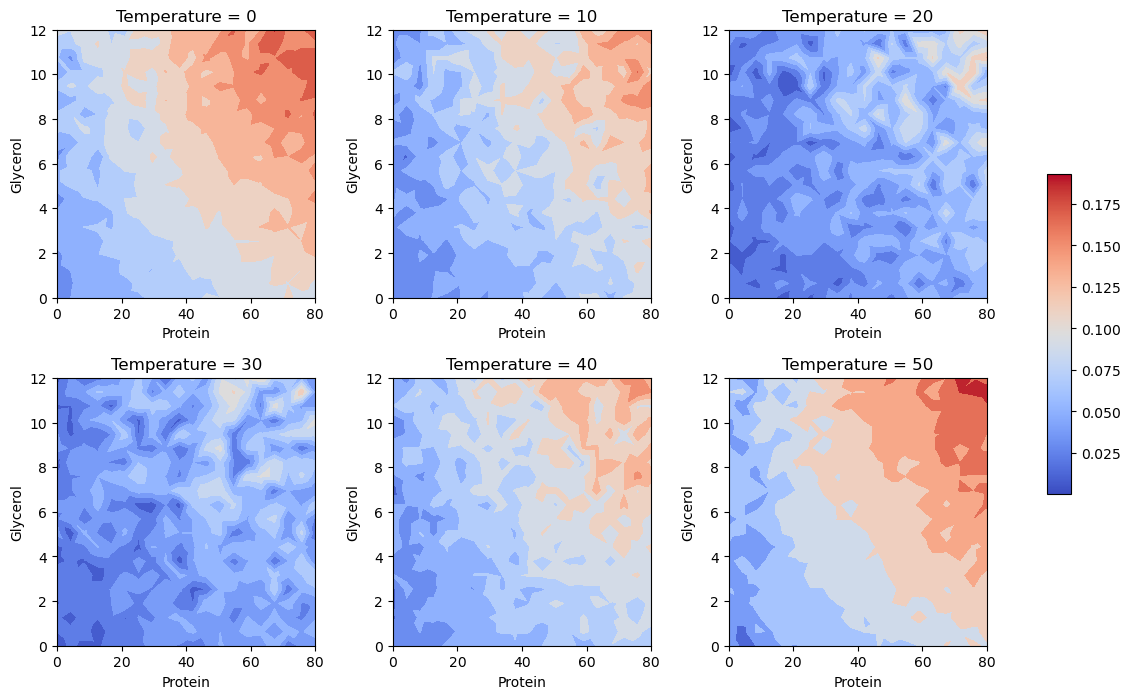

In [14]:
plot_value_slices(ds_result, "design_space_grid", "hierarchy_cost")

## Run AL

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


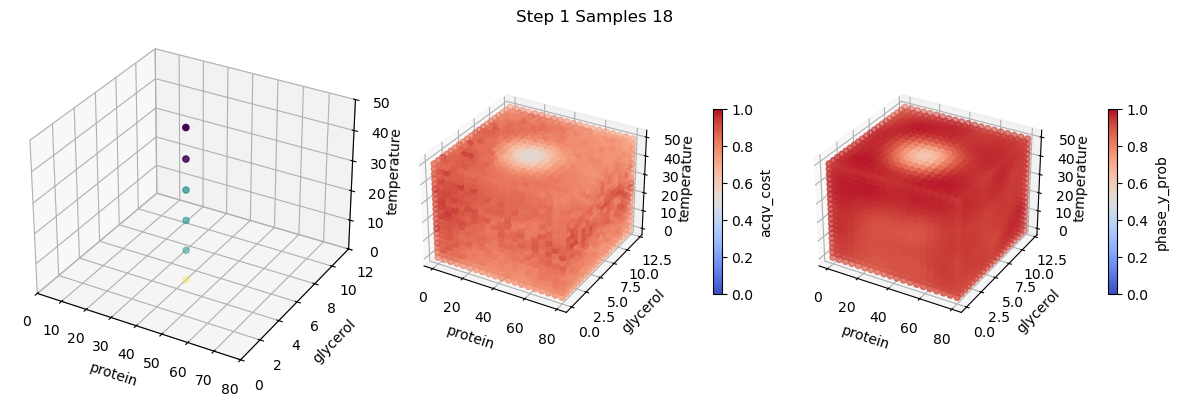

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


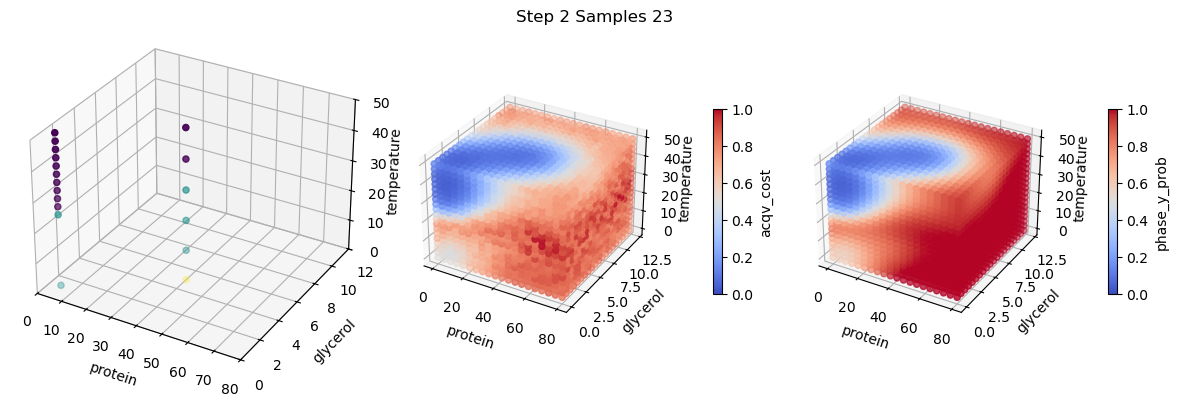

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


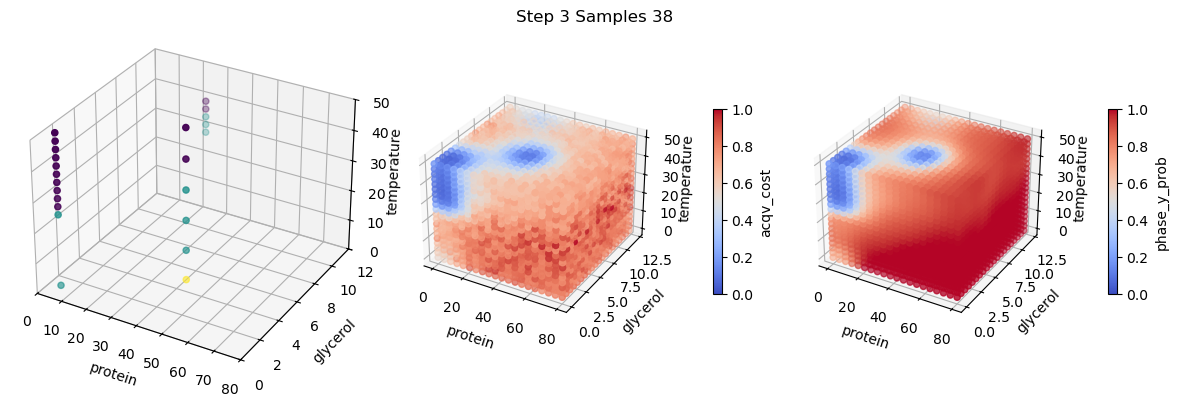

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


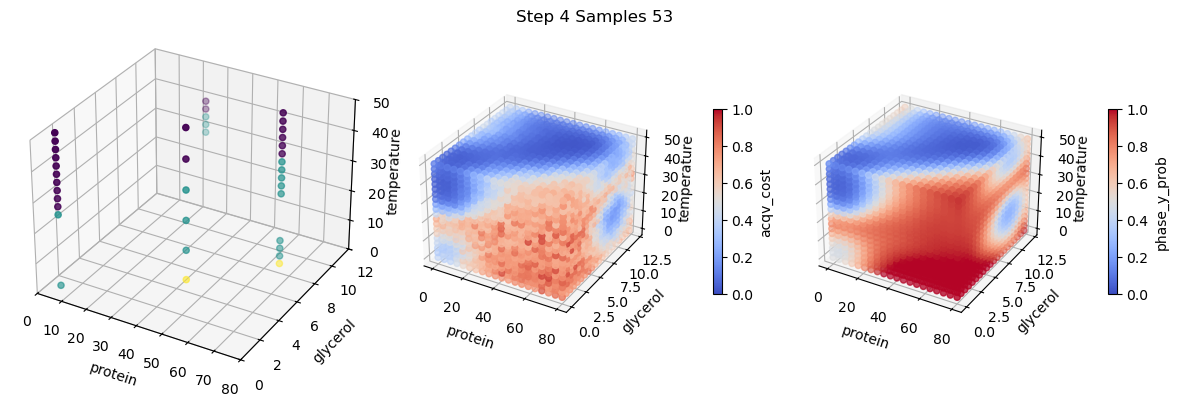

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


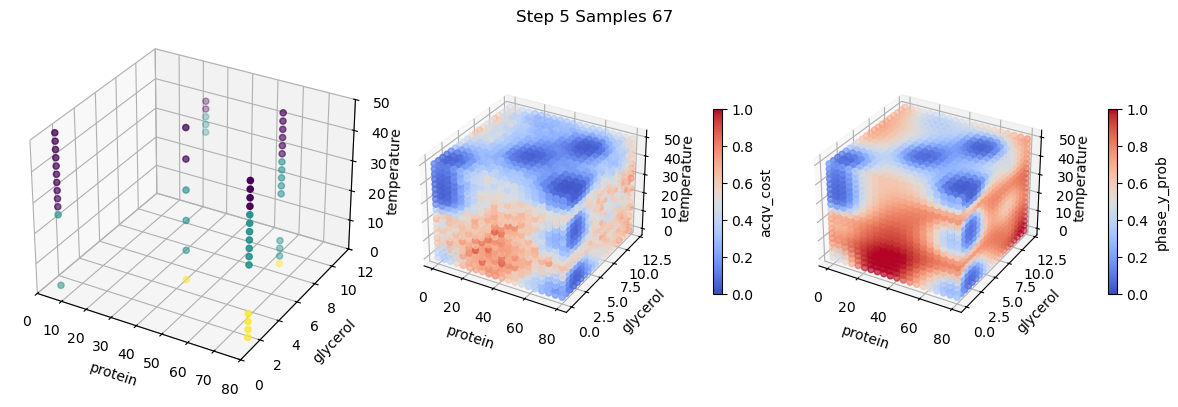

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


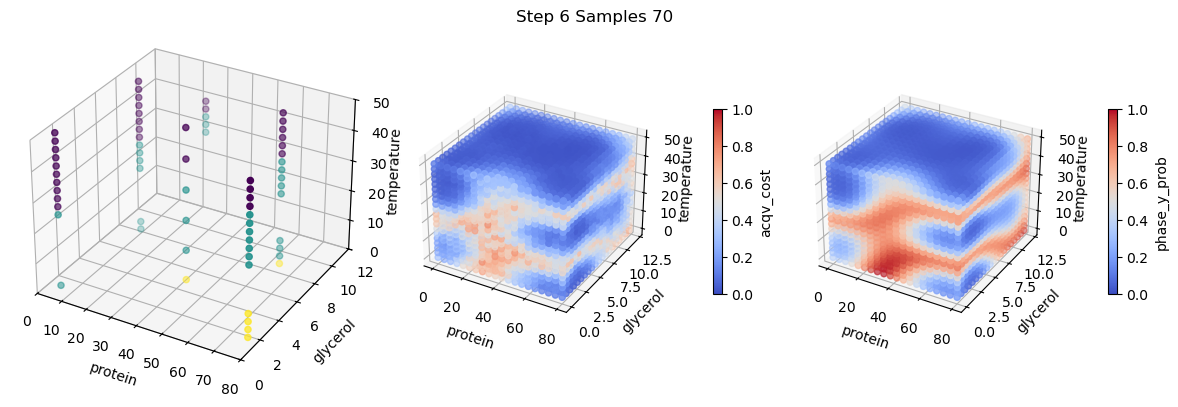

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


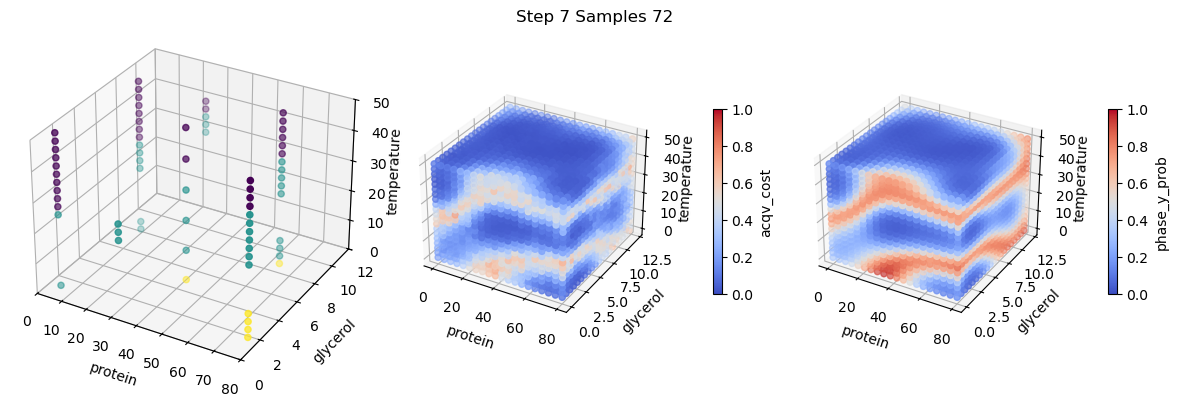

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


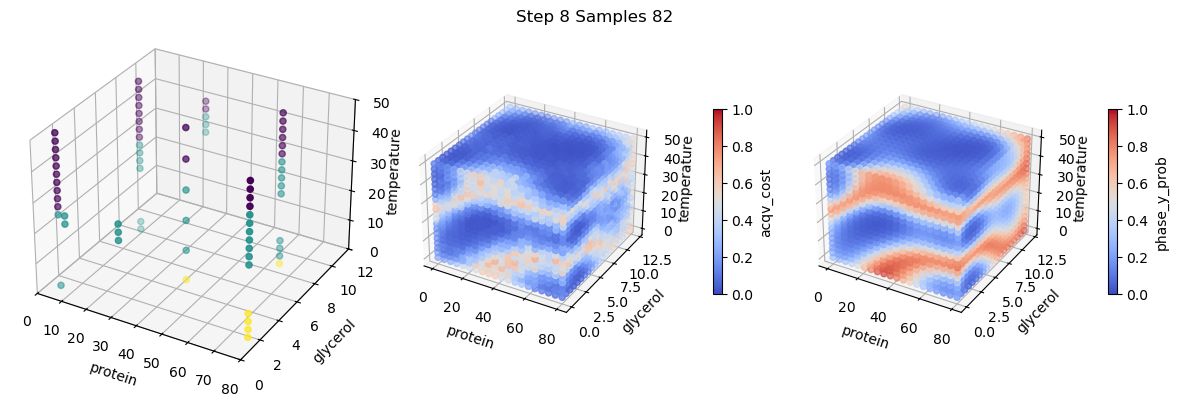

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


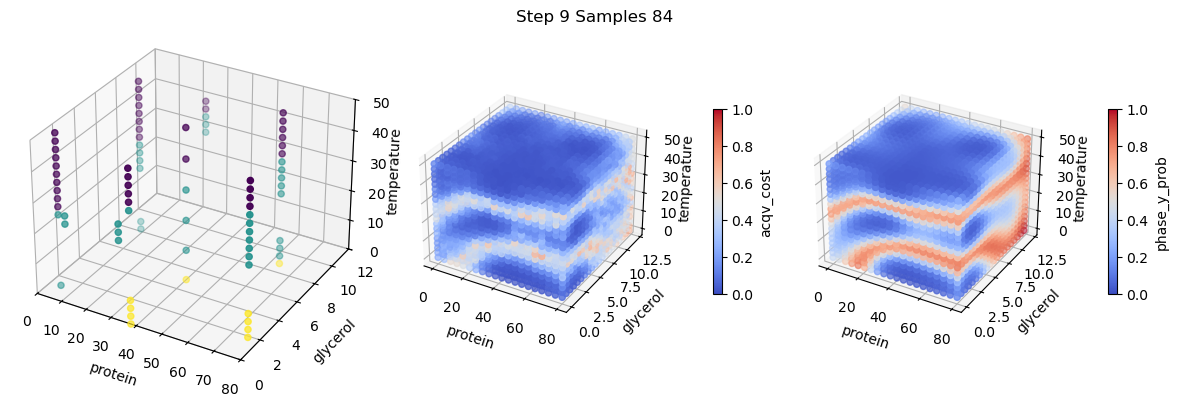

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


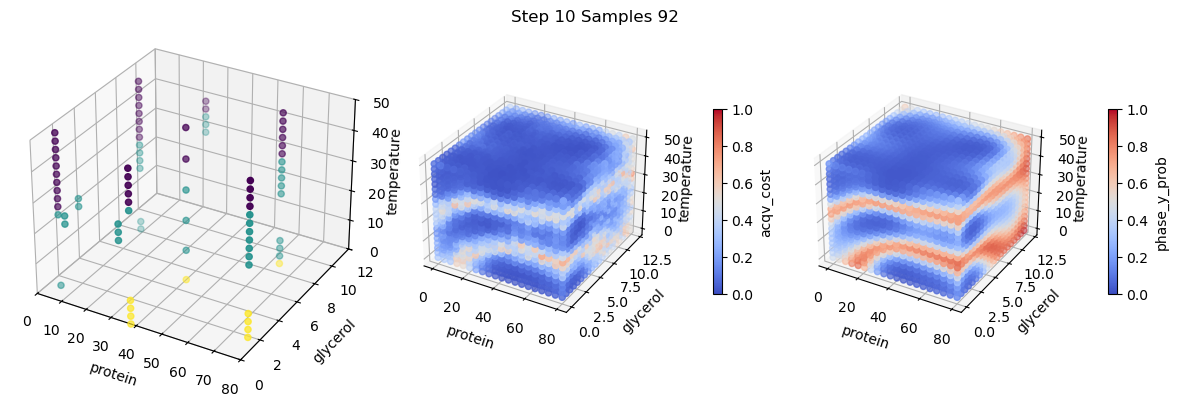

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


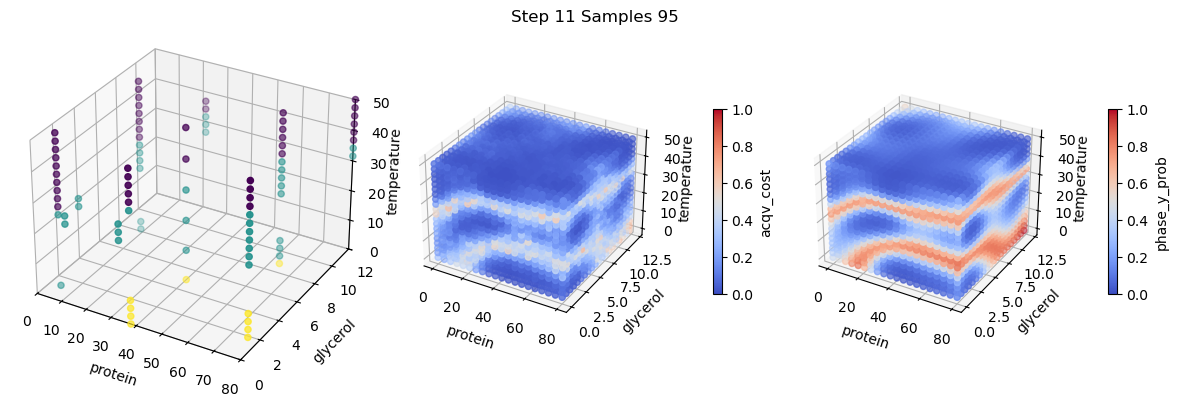

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


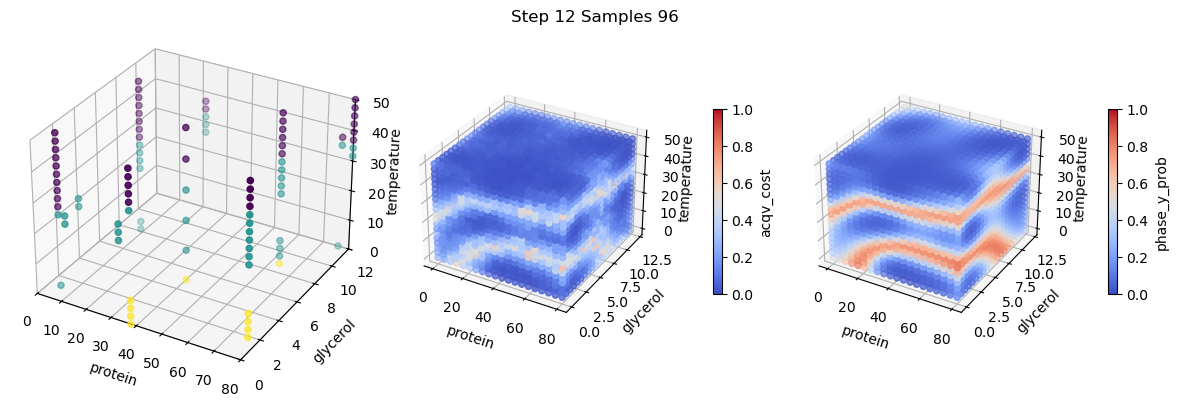

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


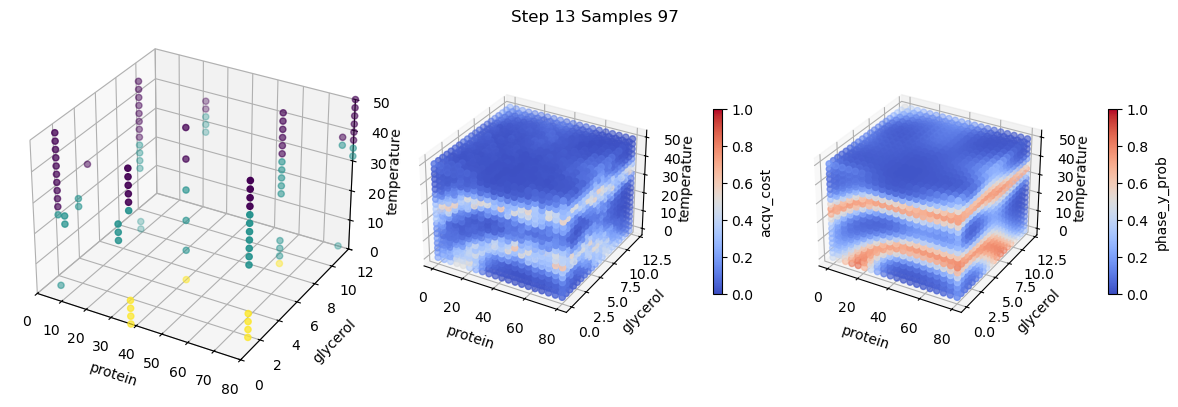

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


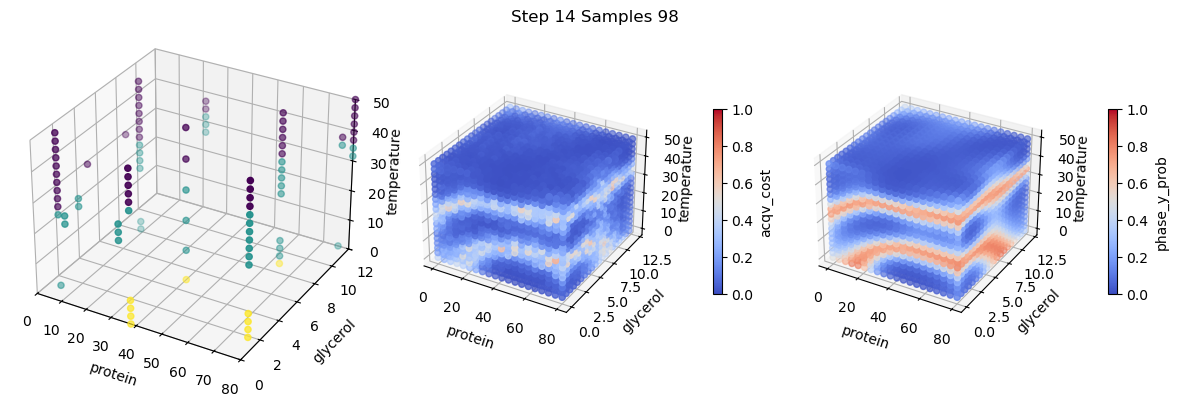

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


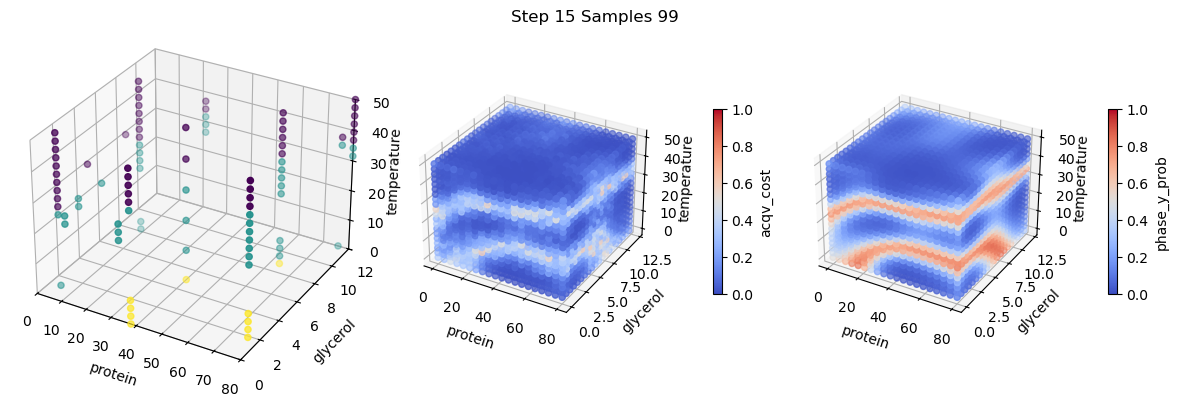

Shape of grid points:  torch.Size([8000, 3])
Shape of grid points:  torch.Size([8000, 3])


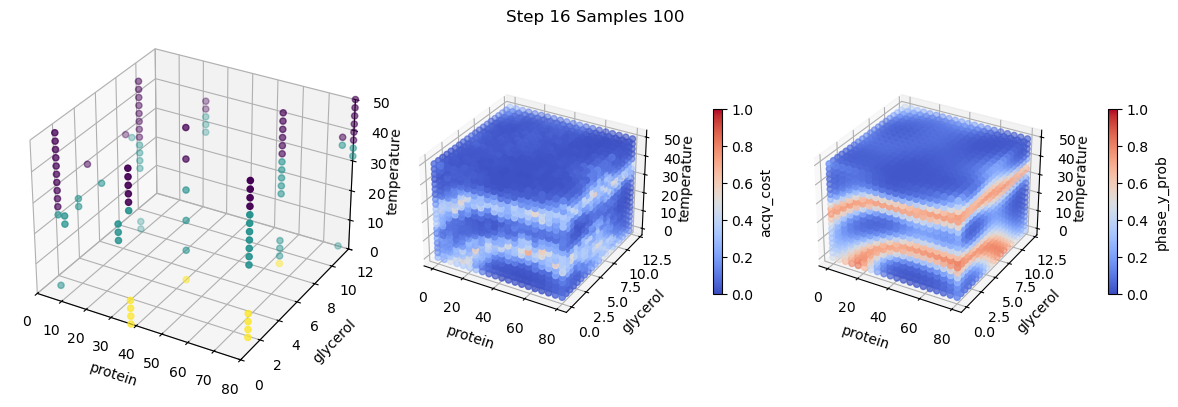

In [15]:
ds_running = ds_init.copy() 

max_samples = 100 
step = 0
while len(ds_running.sample)<max_samples:
    ds_result = p.calculate(ds_running, disable_progress_bar=True)
    next_sample = ds_result['temperature_line_samples'].to_pandas().to_dict(orient='records')    
    ds_new = []
    for sample in next_sample:
        ds = inst_client.simple_expose(sample)
        ds = ds.rename({'composition': 'design_space', 'component':'ds_dim'})
        ds['phases'] = int(ds.attrs['labels'])
        ds_new.append(ds)

    ds_new = xr.concat(ds_new, dim='sample')

    ds_running = xr.concat([ds_running, ds_new], dim='sample')
    fig, axs = plot_progress(ds_result, 
                  "design_space", 
                  "design_space_grid", 
                  "ds_dim", 
                  ['protein', 'glycerol', 'temperature'],
                  "phases",
                  "acqv_cost",
                  "phase_y_prob"
                  )
    fig.suptitle(f"Step {step+1} Samples {len(ds_running.sample)}")
    step += 1
    plt.show()

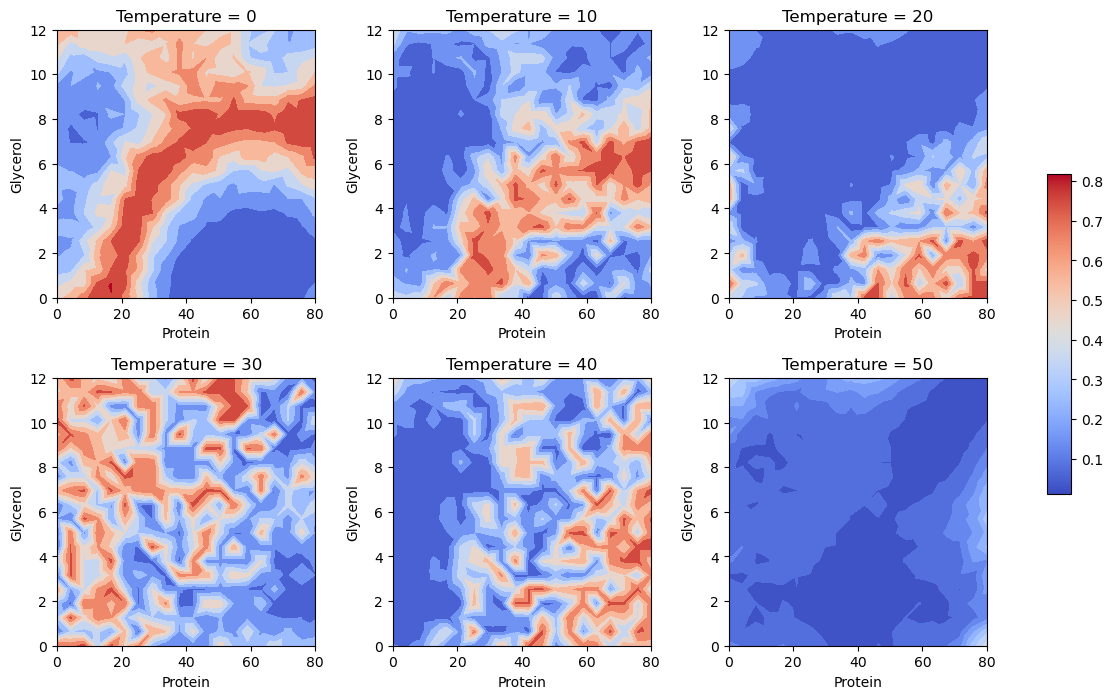

In [16]:
plot_value_slices(ds_result, "design_space_grid", "phase_entropy")

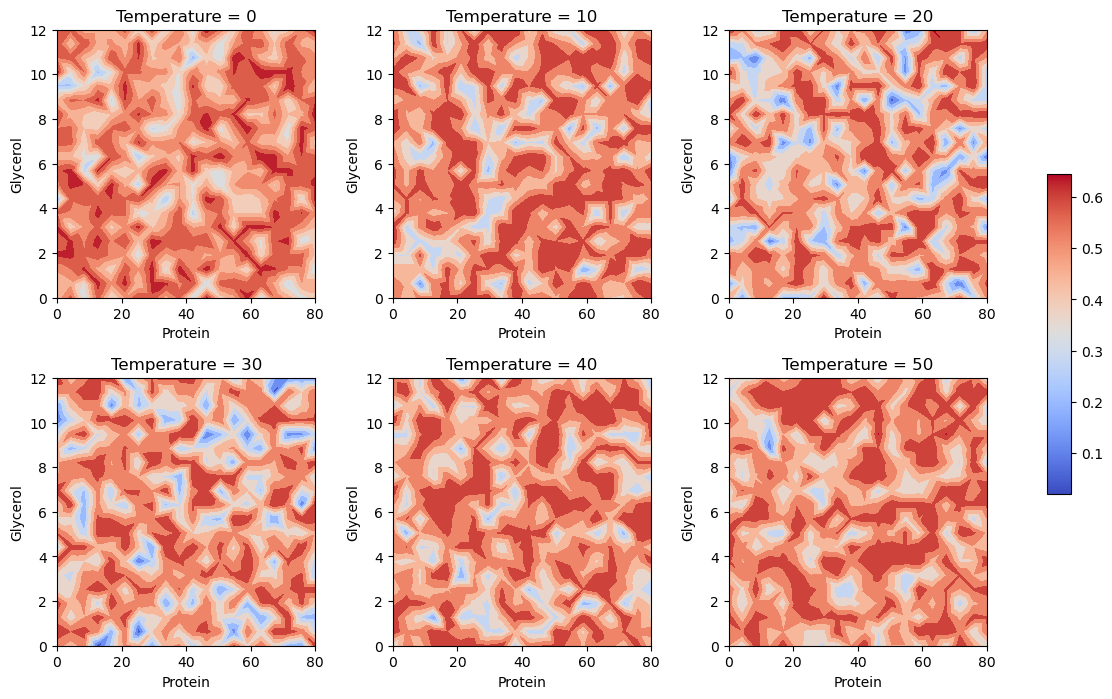

In [17]:
plot_value_slices(ds_result, "design_space_grid", "hierarchy_cost")

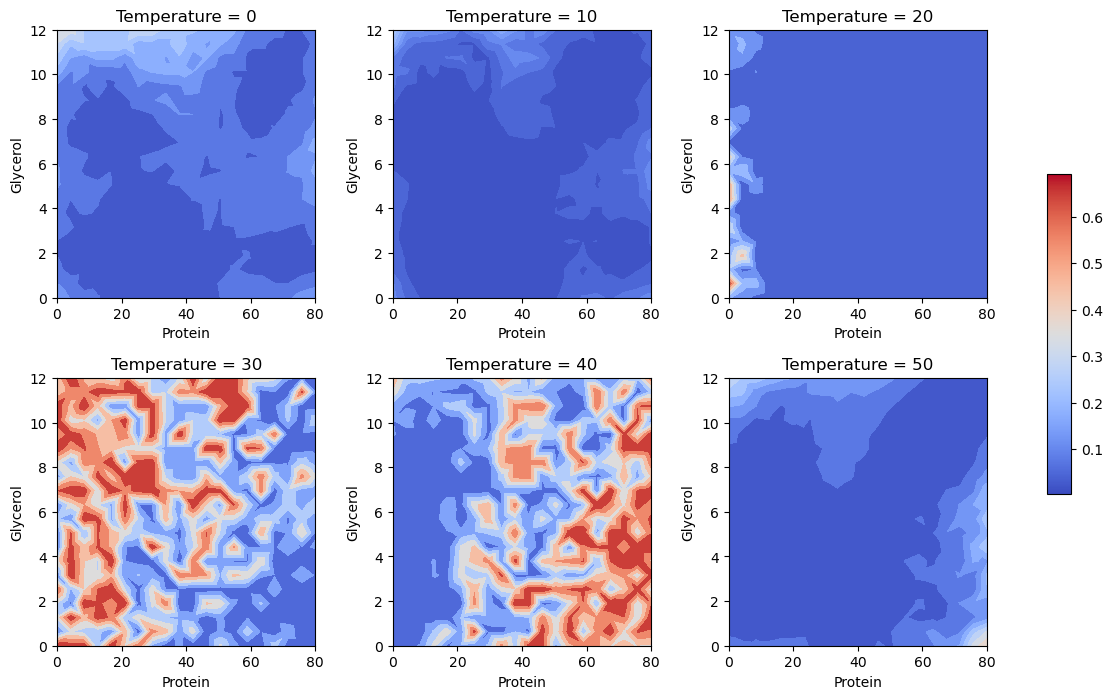

In [18]:
plot_value_slices(ds_result, "design_space_grid", "feasibility_y_prob")

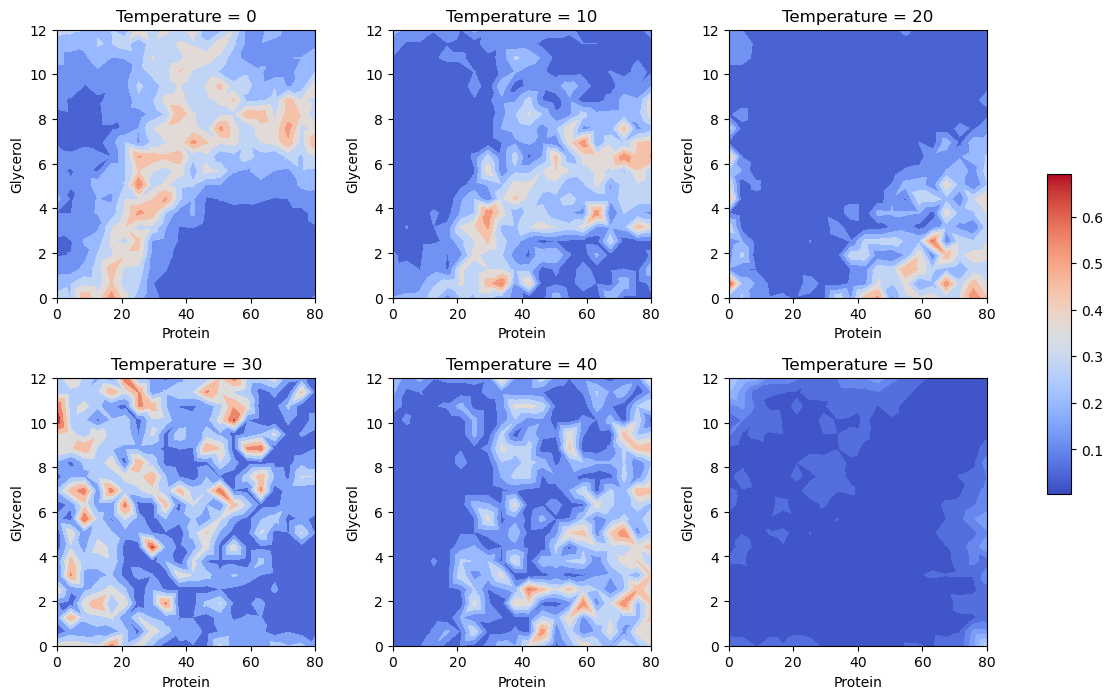

In [19]:
plot_value_slices(ds_result, "design_space_grid", "acqv_cost")

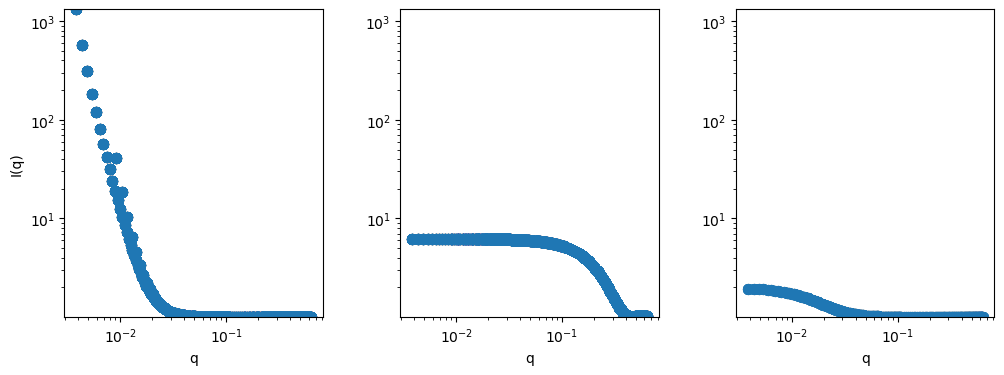

In [20]:
fig, axs = plt.subplots(1,3, figsize=(4*3, 4))
fig.subplots_adjust(wspace=0.3)
axs = axs.flatten()
q = ds_result.q.values 
Iq = ds_result.I.values
labels = ds_result["phases"].values
for label in np.unique(labels):
    ax = axs[label]
    flags = labels == label
    Iq_current_phase = Iq[flags]
    for i in range(Iq_current_phase.shape[0]):
        ax.scatter(q, 
                  Iq_current_phase[i,:], 
                  color="tab:blue", 
                  lw=2.0, 
                  alpha=0.5
                )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("q")
    ax.set_ylim([Iq.min(), Iq.max()])
axs[0].set_ylabel("I(q)")
plt.show()